# Projet Data Mining — Prétraitement des données
**Dataset :** Étude sur la solitude et le capital social (6708 individus, 25 variables)

## Plan
1. Chargement et exploration initiale
2. Prétraitement
   - (a) Valeurs sentinelles (-99)
   - (b) Doublons
   - (c) Valeurs manquantes
   - (d) Détection et traitement des outliers
   - (e) Encodage des variables catégorielles
3. Normalisation et standardisation
4. Séparation train / test
5. Réduction de dimension — ACP (PCA)

---
## 1. Chargement et exploration initiale

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Charger le dataset
df = pd.read_excel('dataset.xlsx')

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 6708 lignes × 25 colonnes


,ID,Gender,Age_Categories,Income,Marital_Status,Carer,Parent,UCLA_Single_Frequency,UCLA_Comp_Often,UCLA_Leftout_Often,...,When_Young,When_Young_Adult,When_Adult,When_Mid_Life,When_Older_Adult,UCLA3_tot,Other_times_count,UCLA3_gp,Marital_Stat3,SRH_gp
0,29,1,8,1.0,4,1.0,2.0,1,1.0,1.0,...,0,0,0,0,0,3.0,0.0,0.0,0.0,3.0
1,41,2,8,3.0,7,1.0,2.0,4,5.0,5.0,...,0,1,0,0,1,9.0,2.0,1.0,3.0,2.0
2,53,1,7,2.0,4,1.0,2.0,3,4.0,3.0,...,1,1,1,1,1,6.0,5.0,1.0,0.0,2.0
3,78,2,7,2.0,7,1.0,2.0,3,4.0,2.0,...,0,0,0,0,0,5.0,0.0,0.0,3.0,1.0
4,83,1,7,1.0,1,1.0,1.0,5,4.0,2.0,...,1,1,1,0,1,7.0,4.0,1.0,1.0,3.0


In [26]:
# Informations générales sur les types et valeurs non-nulles
print(' Informations générales')
df.info()
print('\nStatistiques descriptives ')
df.describe().round(2)

 Informations générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6708 entries, 0 to 6707
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     6708 non-null   int64  
 1   Gender                 6708 non-null   int64  
 2   Age_Categories         6708 non-null   int64  
 3   Income                 6626 non-null   float64
 4   Marital_Status         6708 non-null   int64  
 5   Carer                  6570 non-null   float64
 6   Parent                 6575 non-null   float64
 7   UCLA_Single_Frequency  6708 non-null   int64  
 8   UCLA_Comp_Often        6459 non-null   float64
 9   UCLA_Leftout_Often     6427 non-null   float64
 10  UCLA_Isolated_Often    6382 non-null   float64
 11  Times_Alone            6360 non-null   float64
 12  Other_Times            6352 non-null   float64
 13  Health_Self_Rating     6708 non-null   int64  
 14  Social_Capital         5398 non-

,ID,Gender,Age_Categories,Income,Marital_Status,Carer,Parent,UCLA_Single_Frequency,UCLA_Comp_Often,UCLA_Leftout_Often,...,When_Young,When_Young_Adult,When_Adult,When_Mid_Life,When_Older_Adult,UCLA3_tot,Other_times_count,UCLA3_gp,Marital_Stat3,SRH_gp
count,6708.0,6708.00,6708.00,6626.00,6708.00,6570.00,6575.00,6708.00,6459.00,6427.00,...,6708.00,6708.00,6708.00,6708.00,6708.00,6314.00,6352.00,6314.00,6574.00,5428.00
mean,25173.1,1.71,7.17,2.32,2.91,1.08,1.72,-7.35,2.83,2.41,...,0.25,0.38,0.35,0.35,0.36,5.21,1.79,0.41,1.46,1.84
std,13854.8,1.32,0.38,0.66,14.68,0.27,0.45,30.53,1.35,1.28,...,0.43,0.48,0.48,0.48,0.48,2.21,1.62,0.49,1.17,0.82
min,29.0,-99.00,7.00,1.00,-99.00,1.00,1.00,-99.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,1.00
25%,14199.5,1.00,7.00,2.00,4.00,1.00,1.00,2.00,2.00,1.00,...,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,1.00
50%,27132.5,2.00,7.00,2.00,6.00,1.00,2.00,2.00,3.00,2.00,...,0.00,0.00,0.00,0.00,0.00,5.00,2.00,0.00,2.00,2.00
75%,35950.5,2.00,7.00,3.00,7.00,1.00,2.00,4.00,4.00,3.00,...,1.00,1.00,1.00,1.00,1.00,7.00,3.00,1.00,2.00,3.00
max,49199.0,4.00,8.00,3.00,8.00,2.00,2.00,5.00,5.00,5.00,...,1.00,1.00,1.00,1.00,1.00,9.00,5.00,1.00,3.00,3.00


In [3]:
# Identifier les colonnes numériques continues vs catégorielles
# ID est un identifiant : on l'exclut de toutes les transformations analytiques
ID_COL = 'ID'

# Variables catégorielles (encodées en entiers)
CAT_COLS = ['Gender', 'Marital_Status', 'Carer', 'Parent',
            'When_Young', 'When_Young_Adult', 'When_Adult',
            'When_Mid_Life', 'When_Older_Adult',
            'UCLA3_gp', 'Marital_Stat3', 'SRH_gp']

# Variables numériques continues (à normaliser)
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + [ID_COL]]

print('Colonnes numériques continues :', NUM_COLS)
print('\nColonnes catégorielles :', CAT_COLS)

Colonnes numériques continues : ['Age_Categories', 'Income', 'UCLA_Single_Frequency', 'UCLA_Comp_Often', 'UCLA_Leftout_Often', 'UCLA_Isolated_Often', 'Times_Alone', 'Other_Times', 'Health_Self_Rating', 'Social_Capital', 'UCLA3_tot', 'Other_times_count']

Colonnes catégorielles : ['Gender', 'Marital_Status', 'Carer', 'Parent', 'When_Young', 'When_Young_Adult', 'When_Adult', 'When_Mid_Life', 'When_Older_Adult', 'UCLA3_gp', 'Marital_Stat3', 'SRH_gp']


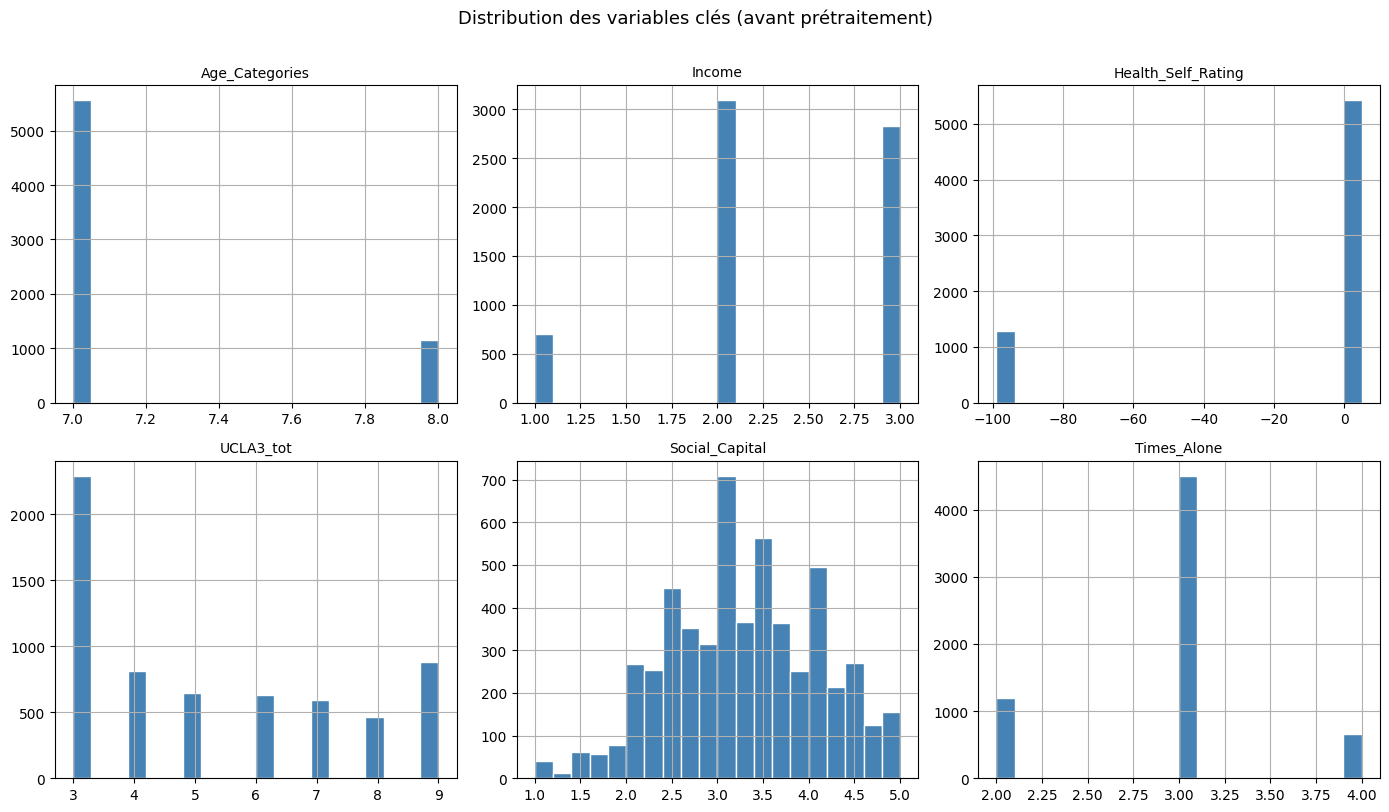

In [4]:
# Visualisation de la distribution de quelques variables clés
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols_to_plot = ['Age_Categories', 'Income', 'Health_Self_Rating',
                'UCLA3_tot', 'Social_Capital', 'Times_Alone']

for ax, col in zip(axes.flatten(), cols_to_plot):
    df[col].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Distribution des variables clés (avant prétraitement)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Prétraitement

### (a) Traitement des valeurs sentinelles (-99)

Dans ce type d'enquête, **-99** est souvent utilisé pour coder "pas de réponse" ou "ne s'applique pas".  
Ces valeurs ne sont **pas** des valeurs numériques légitimes — il faut les remplacer par `NaN` avant toute autre étape.

In [5]:
# Détecter les valeurs sentinelles -99
sentinel_counts = (df == -99).sum()
sentinel_counts = sentinel_counts[sentinel_counts > 0]
print('Colonnes avec valeurs -99 (sentinelles) :')
print(sentinel_counts)

Colonnes avec valeurs -99 (sentinelles) :
Gender                      1
Marital_Status            134
UCLA_Single_Frequency     669
Health_Self_Rating       1280
dtype: int64


In [6]:
# Remplacer toutes les occurrences de -99 par NaN
df.replace(-99, np.nan, inplace=True)

print('Valeurs -99 restantes après remplacement :', (df == -99).sum().sum())

Valeurs -99 restantes après remplacement : 0


### (b) Suppression des doublons

In [7]:
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)

print(f'Doublons supprimés : {n_before - n_after}')
print(f'Lignes restantes   : {n_after}')

Doublons supprimés : 0
Lignes restantes   : 6708


### (c) Traitement des valeurs manquantes

Valeurs manquantes par colonne :
                       Manquants  Pourcentage (%)
Social_Capital              1310            19.53
Health_Self_Rating          1280            19.08
SRH_gp                      1280            19.08
UCLA_Single_Frequency        669             9.97
UCLA3_tot                    394             5.87
UCLA3_gp                     394             5.87
Other_Times                  356             5.31
Other_times_count            356             5.31
Times_Alone                  348             5.19
UCLA_Isolated_Often          326             4.86
UCLA_Leftout_Often           281             4.19
UCLA_Comp_Often              249             3.71
Carer                        138             2.06
Marital_Status               134             2.00
Marital_Stat3                134             2.00
Parent                       133             1.98
Income                        82             1.22
Gender                         1             0.01


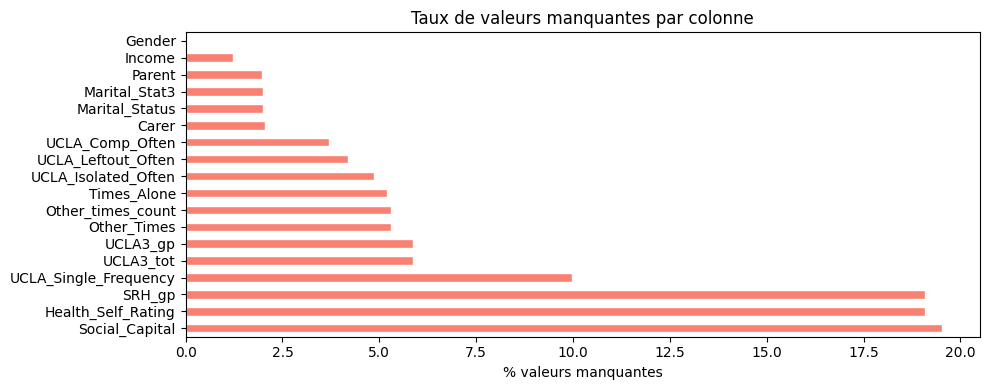

In [8]:
# Carte des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Pourcentage (%)', ascending=False)

print('Valeurs manquantes par colonne :')
print(missing_df)

# Visualisation
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Pourcentage (%)'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
    ax.set_xlabel('% valeurs manquantes')
    ax.set_title('Taux de valeurs manquantes par colonne')
    plt.tight_layout()
    plt.show()

In [9]:
# Imputation :
#   - Variables numériques continues → médiane (robuste aux outliers)
#   - Variables catégorielles       → mode (valeur la plus fréquente)

for col in NUM_COLS:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  [{col}] → imputation médiane = {median_val:.2f}')

for col in CAT_COLS:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  [{col}] → imputation mode = {mode_val}')

print(f'\nValeurs manquantes restantes : {df.isnull().sum().sum()}')

  [Income] → imputation médiane = 2.00
  [UCLA_Single_Frequency] → imputation médiane = 3.00
  [UCLA_Comp_Often] → imputation médiane = 3.00
  [UCLA_Leftout_Often] → imputation médiane = 2.00
  [UCLA_Isolated_Often] → imputation médiane = 2.00
  [Times_Alone] → imputation médiane = 3.00
  [Other_Times] → imputation médiane = 2.00
  [Health_Self_Rating] → imputation médiane = 3.00
  [Social_Capital] → imputation médiane = 3.29
  [UCLA3_tot] → imputation médiane = 5.00
  [Other_times_count] → imputation médiane = 2.00
  [Gender] → imputation mode = 2.0
  [Marital_Status] → imputation mode = 6.0
  [Carer] → imputation mode = 1.0
  [Parent] → imputation mode = 2.0
  [UCLA3_gp] → imputation mode = 0.0
  [Marital_Stat3] → imputation mode = 0.0
  [SRH_gp] → imputation mode = 1.0

Valeurs manquantes restantes : 0


### (d) Détection et traitement des outliers (valeurs aberrantes)

Méthode **IQR (Interquartile Range)** : une valeur est considérée aberrante si elle est en dehors de l'intervalle `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.  
On applique cela uniquement aux variables numériques continues.

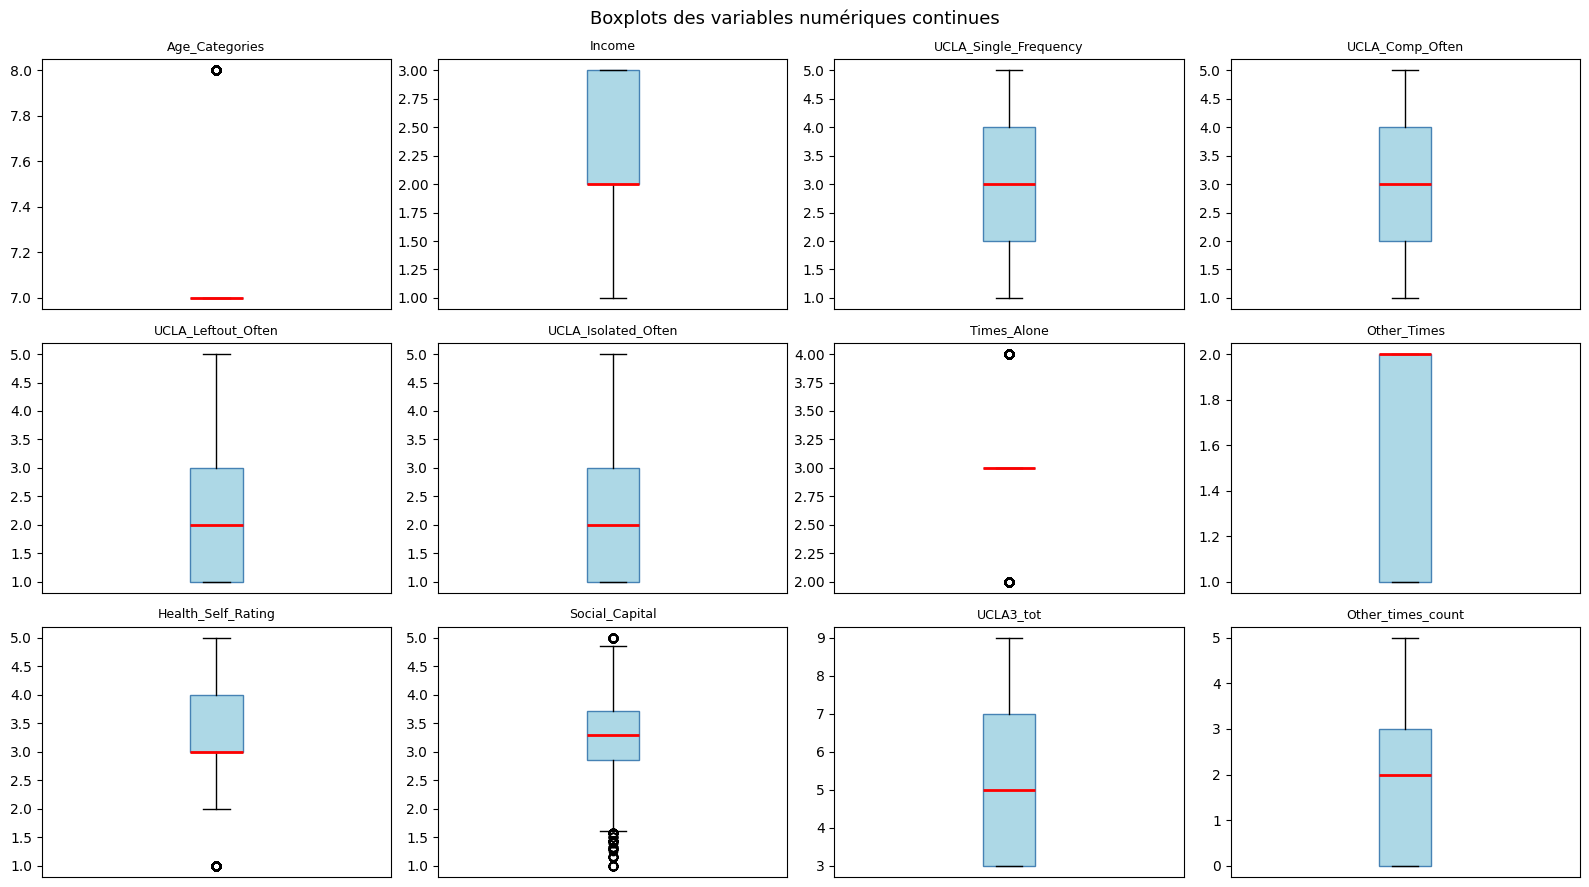

In [10]:
# Visualisation des outliers avec boxplots
n_cols = 4
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots des variables numériques continues', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Comptage des outliers par colonne
outlier_report = {}
for col in NUM_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'Borne inf.': round(lower, 2), 'Borne sup.': round(upper, 2),
        'Outliers': n_out,
        'Outliers (%)': round(n_out / len(df) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_report).T
print('Rapport des outliers (IQR) :')
print(outlier_df[outlier_df['Outliers'] > 0].sort_values('Outliers (%)', ascending=False))

Rapport des outliers (IQR) :
                      Q1    Q3  Borne inf.  Borne sup.  Outliers  Outliers (%)
Times_Alone         3.00  3.00        3.00         3.0    1856.0         27.67
Age_Categories      7.00  7.00        7.00         7.0    1144.0         17.05
Health_Self_Rating  3.00  4.00        1.50         5.5     378.0          5.64
Social_Capital      2.86  3.71        1.57         5.0     203.0          3.03


In [12]:
# Traitement : écrêtage (capping) au lieu de suppression
# → On ramène les valeurs extrêmes aux bornes IQR (préserve les lignes)

df_clean = df.copy()

for col in NUM_COLS:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f'Données nettoyées : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes')
print('Toutes les valeurs aberrantes ont été écrêtées (capping IQR).')

Données nettoyées : 6708 lignes × 25 colonnes
Toutes les valeurs aberrantes ont été écrêtées (capping IQR).


### (e) Encodage des variables catégorielles

Les variables catégorielles à 2 modalités (binaires) sont déjà en 0/1 ou 1/2 — on les recod en 0/1.  
Pour les variables nominales avec plus de 2 modalités, on utilise **OneHotEncoding**.

In [13]:
# Aperçu des modalités de chaque variable catégorielle
print('Modalités uniques par variable catégorielle :')
for col in CAT_COLS:
    vals = sorted(df_clean[col].unique().tolist())
    print(f'  {col} → {vals}')

Modalités uniques par variable catégorielle :
  Gender → [1.0, 2.0, 3.0, 4.0]
  Marital_Status → [1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
  Carer → [1.0, 2.0]
  Parent → [1.0, 2.0]
  When_Young → [0, 1]
  When_Young_Adult → [0, 1]
  When_Adult → [0, 1]
  When_Mid_Life → [0, 1]
  When_Older_Adult → [0, 1]
  UCLA3_gp → [0.0, 1.0]
  Marital_Stat3 → [0.0, 1.0, 2.0, 3.0]
  SRH_gp → [1.0, 2.0, 3.0]


In [14]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()

# Variables binaires : recoder en 0/1
binary_cols = ['Carer', 'Parent',
               'When_Young', 'When_Young_Adult', 'When_Adult',
               'When_Mid_Life', 'When_Older_Adult']

for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(int))
    print(f'  {col} → {dict(enumerate(le.classes_))}')

# Variables ordinales à plusieurs niveaux → LabelEncoder suffit
ordinal_cols = ['Gender', 'Marital_Status', 'UCLA3_gp', 'Marital_Stat3', 'SRH_gp']

for col in ordinal_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(int))

print('\nEncodage terminé.')
print(f'Shape après encodage : {df_encoded.shape}')

  Carer → {0: np.int64(1), 1: np.int64(2)}
  Parent → {0: np.int64(1), 1: np.int64(2)}
  When_Young → {0: np.int64(0), 1: np.int64(1)}
  When_Young_Adult → {0: np.int64(0), 1: np.int64(1)}
  When_Adult → {0: np.int64(0), 1: np.int64(1)}
  When_Mid_Life → {0: np.int64(0), 1: np.int64(1)}
  When_Older_Adult → {0: np.int64(0), 1: np.int64(1)}

Encodage terminé.
Shape après encodage : (6708, 25)


---
## 3. Normalisation et standardisation

On exclut la colonne `ID` (identifiant) de toutes les transformations.  
On applique la **normalisation Min-Max** sur les variables continues et on garde les catégorielles encodées telles quelles.

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Séparer l'ID
df_ids = df_encoded[[ID_COL]].copy()

# Features analytiques (sans ID)
feature_cols = [c for c in df_encoded.columns if c != ID_COL]
df_features = df_encoded[feature_cols].copy()

# Appliquer Min-Max UNIQUEMENT sur les numériques continues
scaler_minmax = MinMaxScaler()
df_features[NUM_COLS] = scaler_minmax.fit_transform(df_features[NUM_COLS])

print('Normalisation Min-Max appliquée sur les colonnes numériques continues.')
print('Vérification min/max après normalisation :')
print(df_features[NUM_COLS].agg(['min', 'max']).round(4))

Normalisation Min-Max appliquée sur les colonnes numériques continues.
Vérification min/max après normalisation :
     Age_Categories  Income  UCLA_Single_Frequency  UCLA_Comp_Often  \
min             0.0     0.0                    0.0              0.0   
max             0.0     1.0                    1.0              1.0   

     UCLA_Leftout_Often  UCLA_Isolated_Often  Times_Alone  Other_Times  \
min                 0.0                  0.0          0.0          0.0   
max                 1.0                  1.0          0.0          1.0   

     Health_Self_Rating  Social_Capital  UCLA3_tot  Other_times_count  
min                 0.0             0.0        0.0                0.0  
max                 1.0             1.0        1.0                1.0  


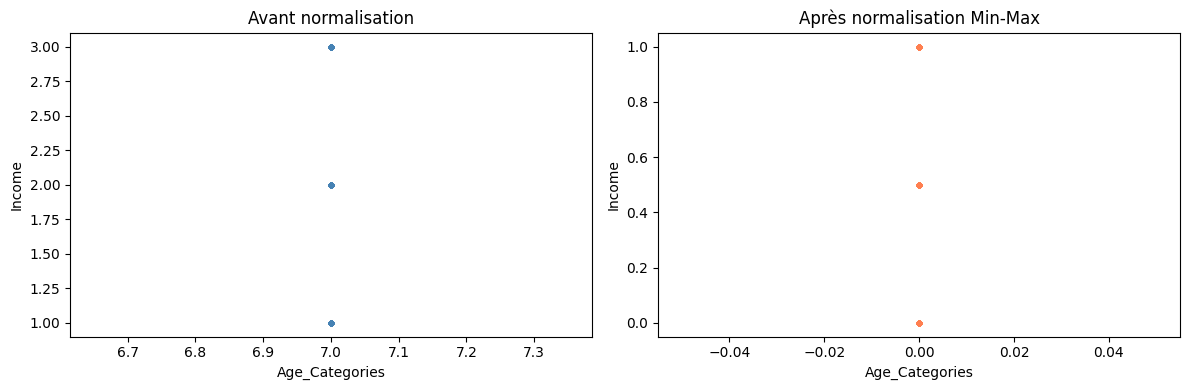

In [16]:
# Visualisation avant / après normalisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_clean['Age_Categories'], df_clean['Income'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Avant normalisation')
axes[0].set_xlabel('Age_Categories')
axes[0].set_ylabel('Income')

axes[1].scatter(df_features['Age_Categories'], df_features['Income'],
                alpha=0.3, s=10, color='coral')
axes[1].set_title('Après normalisation Min-Max')
axes[1].set_xlabel('Age_Categories')
axes[1].set_ylabel('Income')

plt.tight_layout()
plt.show()

---
## 4. Séparation Train / Test

La séparation doit être faite **avant** la PCA pour éviter le **data leakage** (fuite d'information).  
On utilise un ratio 80/20 classique.

In [17]:
from sklearn.model_selection import train_test_split

X = df_features.values

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f'Ensemble d\'entraînement : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Ensemble de test        : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)')

Ensemble d'entraînement : 5366 lignes (80.0%)
Ensemble de test        : 1342 lignes (20.0%)


---
## 5. Réduction de dimension — ACP (PCA)

Avant la PCA, on applique une **standardisation Z-score** (`StandardScaler`) sur le train.  
On fit le scaler sur le train seulement, puis on transforme le test (pas de leakage).

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardisation Z-score (fit sur train uniquement)
scaler_std = StandardScaler()
X_train_scaled = scaler_std.fit_transform(X_train)
X_test_scaled  = scaler_std.transform(X_test)   # même scaler, pas de fit

print('Standardisation Z-score appliquée (fit sur train uniquement).')

Standardisation Z-score appliquée (fit sur train uniquement).


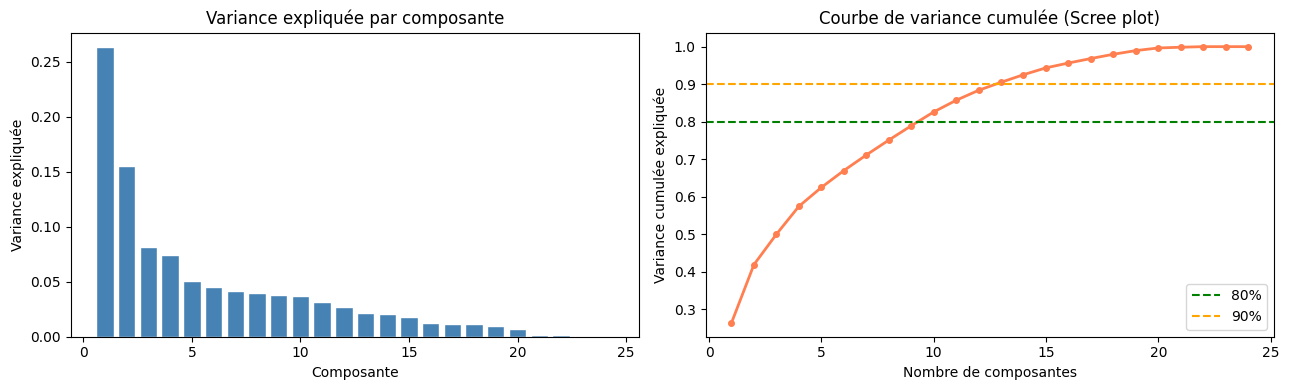

Composantes pour 80% de variance : 10
Composantes pour 90% de variance : 13


In [19]:
# PCA complète pour analyser la variance expliquée
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumvar = pca_full.explained_variance_ratio_.cumsum()

# Graphe variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée')
axes[0].set_title('Variance expliquée par composante')

axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4,
             color='coral', linewidth=2)
axes[1].axhline(0.80, color='green', linestyle='--', label='80%')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée expliquée')
axes[1].set_title('Courbe de variance cumulée (Scree plot)')
axes[1].legend()

plt.tight_layout()
plt.show()

n_80 = (cumvar < 0.80).sum() + 1
n_90 = (cumvar < 0.90).sum() + 1
print(f'Composantes pour 80% de variance : {n_80}')
print(f'Composantes pour 90% de variance : {n_90}')

In [20]:
# PCA finale — on choisit 80% de variance expliquée
pca = PCA(n_components=0.80, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Dimensions initiales (train)   : {X_train_scaled.shape}')
print(f'Dimensions après PCA  (train)  : {X_train_pca.shape}')
print(f'Variance totale expliquée      : {pca.explained_variance_ratio_.sum():.4f}')
print(f'Nombre de composantes retenues : {pca.n_components_}')

Dimensions initiales (train)   : (5366, 24)
Dimensions après PCA  (train)  : (5366, 10)
Variance totale expliquée      : 0.8257
Nombre de composantes retenues : 10


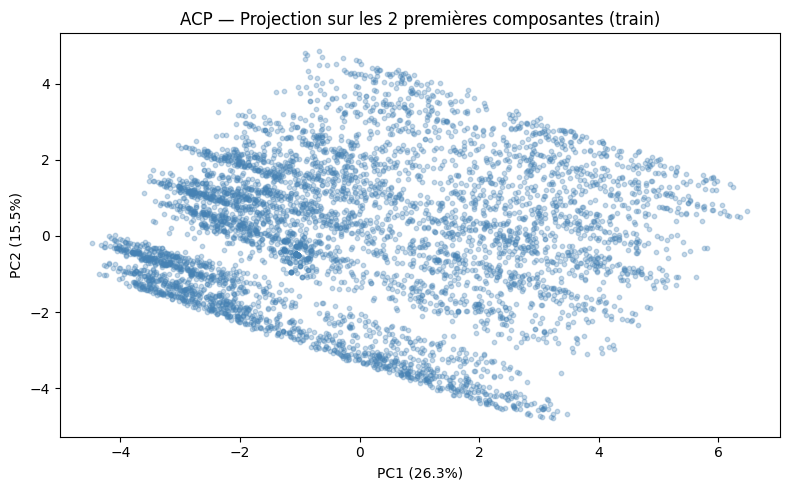

In [21]:
# Visualisation PC1 vs PC2 (train)
pca_df_train = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])

plt.figure(figsize=(8, 5))
plt.scatter(pca_df_train['PC1'], pca_df_train['PC2'],
            alpha=0.3, s=10, color='steelblue')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('ACP — Projection sur les 2 premières composantes (train)')
plt.tight_layout()
plt.show()

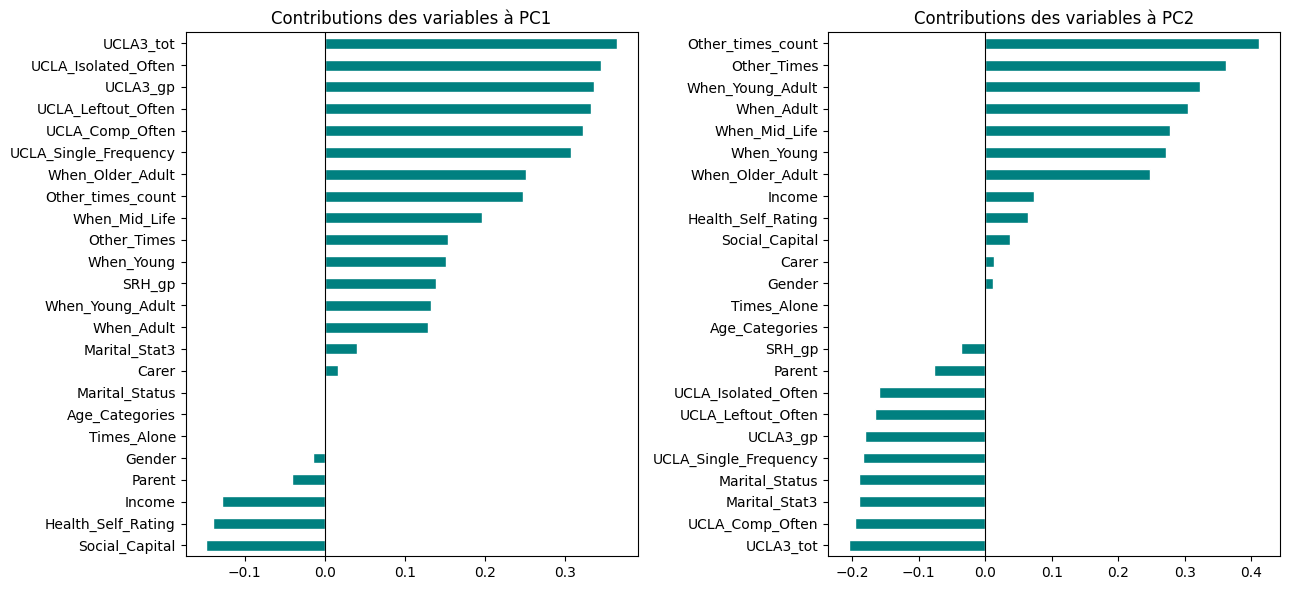

Top 5 variables contribuant à PC1 :
UCLA3_tot              0.365
UCLA_Isolated_Often    0.345
UCLA3_gp               0.336
UCLA_Leftout_Often     0.333
UCLA_Comp_Often        0.323
Name: PC1, dtype: float64


In [22]:
# Contribution des variables originales à PC1 et PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feature_cols,
    columns=['PC1', 'PC2']
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    loadings[pc].sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Contributions des variables à {pc}')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('Top 5 variables contribuant à PC1 :')
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

---
## Résumé du pipeline de prétraitement

| Étape | Action | Résultat |
|---|---|---|
| 1. Valeurs sentinelles | -99 → NaN | Données corrompues nettoyées |
| 2. Doublons | drop_duplicates() | 0 doublon supprimé |
| 3. Valeurs manquantes | Médiane (num.) / Mode (cat.) | 0 valeur manquante |
| 4. Outliers | Écrêtage IQR (capping) | Valeurs extrêmes bornées |
| 5. Encodage | LabelEncoder (0/1) | Variables catégorielles prêtes |
| 6. Normalisation | Min-Max sur numériques | [0, 1] pour variables continues |
| 7. Train/Test split | 80/20 | Pas de data leakage |
| 8. Standardisation | Z-score (fit sur train) | Moyenne=0, Écart-type=1 |
| 9. PCA | 80% de variance | Réduction dimensionnelle |

Les données `X_train_pca` et `X_test_pca` sont prêtes pour la modélisation.

In [23]:
# Résumé final
print('=== RÉSUMÉ FINAL DU PIPELINE ===')
print(f'  Dataset original       : {df.shape}')
print(f'  Après nettoyage        : {df_features.shape}')
print(f'  X_train (avant PCA)    : {X_train_scaled.shape}')
print(f'  X_train (après PCA)    : {X_train_pca.shape}')
print(f'  X_test  (après PCA)    : {X_test_pca.shape}')
print(f'  Variance expliquée PCA : {pca.explained_variance_ratio_.sum():.2%}')

=== RÉSUMÉ FINAL DU PIPELINE ===
  Dataset original       : (6708, 25)
  Après nettoyage        : (6708, 24)
  X_train (avant PCA)    : (5366, 24)
  X_train (après PCA)    : (5366, 10)
  X_test  (après PCA)    : (1342, 10)
  Variance expliquée PCA : 82.57%
